In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
 
# =============================================================
# PROJECT 4 — Customer Segmentation with K-Means Clustering
# Type     : Unsupervised Machine Learning
# Goal     : Automatically discover customer groups
# Features : Age + Monthly Spending (SAR)
# Dataset  : 300 synthetic Saudi customers
# =============================================================
 
os.makedirs("data", exist_ok=True)
 
# ─────────────────────────────────────────────
# STEP 1: Generate Realistic Customer Data
# We simulate 300 customers across 3 natural groups:
#   Group A — Young (age ~25, moderate spending)
#   Group B — High Value (age ~45, high spending)
#   Group C — Senior (age ~60, low spending)
# In a real project this would be loaded from customers.csv
# ─────────────────────────────────────────────
 
print("=" * 65)
print("STEP 1 — Generate and Load Customer Data")
print("=" * 65)
 
np.random.seed(42)
 
# Group A: Young customers (~80 customers)
age_young    = np.random.normal(loc=25,  scale=4,    size=80).clip(18, 35)
spend_young  = np.random.normal(loc=3070, scale=600, size=80).clip(1000, 5000)
 
# Group B: High Value customers (~120 customers)
age_high     = np.random.normal(loc=45,  scale=5,    size=120).clip(35, 58)
spend_high   = np.random.normal(loc=6949, scale=800, size=120).clip(4000, 10000)
 
# Group C: Senior customers (~100 customers)
age_senior   = np.random.normal(loc=60,  scale=5,    size=100).clip(55, 75)
spend_senior = np.random.normal(loc=1954, scale=400, size=100).clip(500, 3500)
 
df = pd.DataFrame({
    'age':              np.concatenate([age_young,   age_high,   age_senior]),
    'monthly_spending': np.concatenate([spend_young, spend_high, spend_senior])
}).round(0).astype(int).reset_index(drop=True)
 
# Save to CSV (as referenced in README project structure)
df.to_csv("data/customers.csv", index=False)
 
print(f"Total customers    : {len(df)}")
print(f"Average age        : {df['age'].mean():.1f} years")
print(f"Average spending   : {df['monthly_spending'].mean():,.0f} SAR")
print(f"Age range          : {df['age'].min()} – {df['age'].max()} years")
print(f"Spending range     : {df['monthly_spending'].min():,} – {df['monthly_spending'].max():,} SAR")
print(f"\nData saved → 'data/customers.csv'")
print(f"\nFirst 10 rows:\n{df.head(10).to_string(index=False)}")
 

STEP 1 — Generate and Load Customer Data
Total customers    : 300
Average age        : 44.7 years
Average spending   : 4,270 SAR
Age range          : 18 – 75 years
Spending range     : 965 – 8,701 SAR

Data saved → 'data/customers.csv'

First 10 rows:
 age  monthly_spending
  27              2938
  24              3284
  28              3957
  31              2759
  24              2585
  24              2769
  31              3619
  28              3267
  23              2752
  27              3378



STEP 2 — Exploratory Data Analysis (EDA)


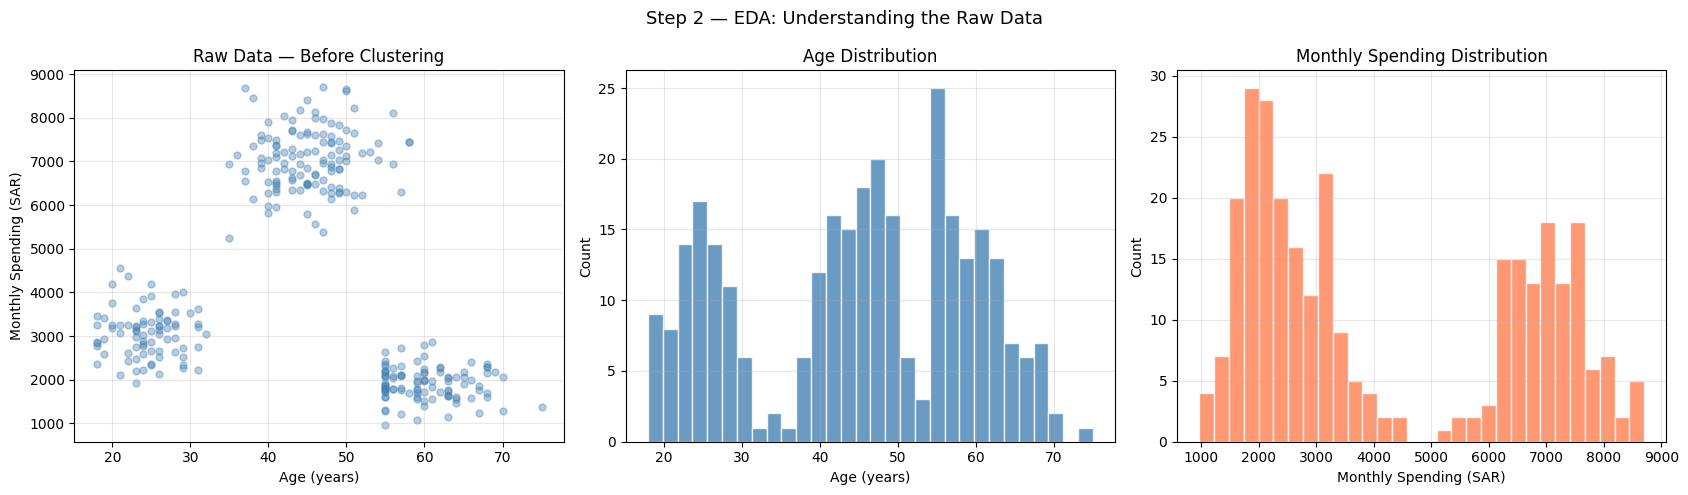

→ We can visually spot ~3 natural clusters in the scatter plot.
→ The algorithm will confirm and precisely define them.


In [2]:
# ─────────────────────────────────────────────
# STEP 2: Exploratory Data Analysis (EDA)
# Visualize the raw data BEFORE clustering.
# We look for natural groupings that the algorithm should find.
# ─────────────────────────────────────────────
 
print("\n" + "=" * 65)
print("STEP 2 — Exploratory Data Analysis (EDA)")
print("=" * 65)
 
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Step 2 — EDA: Understanding the Raw Data", fontsize=13)
 
# Plot 1: Raw scatter — can we see natural groups?
axes[0].scatter(df['age'], df['monthly_spending'],
                alpha=0.4, color='steelblue', s=25)
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Monthly Spending (SAR)')
axes[0].set_title('Raw Data — Before Clustering')
axes[0].grid(True, alpha=0.3)
 
# Plot 2: Age distribution
axes[1].hist(df['age'], bins=30, color='steelblue',
             edgecolor='white', alpha=0.8)
axes[1].set_xlabel('Age (years)')
axes[1].set_ylabel('Count')
axes[1].set_title('Age Distribution')
axes[1].grid(True, alpha=0.3)
 
# Plot 3: Spending distribution
axes[2].hist(df['monthly_spending'], bins=30, color='coral',
             edgecolor='white', alpha=0.8)
axes[2].set_xlabel('Monthly Spending (SAR)')
axes[2].set_ylabel('Count')
axes[2].set_title('Monthly Spending Distribution')
axes[2].grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig("eda_raw_data.png", dpi=150)
plt.show()
 
print("→ We can visually spot ~3 natural clusters in the scatter plot.")
print("→ The algorithm will confirm and precisely define them.")

In [3]:
# ─────────────────────────────────────────────
# STEP 3: Feature Scaling with StandardScaler
# K-Means uses DISTANCE to measure similarity.
# Without scaling:
#   Age range     : 18–75    (range ≈ 57)
#   Spending range: 500–10000 (range ≈ 9500)
#   → Spending dominates completely → clustering ignores age
# With scaling:
#   Both features: mean=0, std=1 → equal contribution
# ─────────────────────────────────────────────
 
print("\n" + "=" * 65)
print("STEP 3 — Feature Scaling (StandardScaler)")
print("=" * 65)
 
X = df[['age', 'monthly_spending']].values
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)
 
print("Before scaling:")
print(f"  Age       — mean: {X[:,0].mean():.1f},  std: {X[:,0].std():.1f},  range: {X[:,0].min():.0f}–{X[:,0].max():.0f}")
print(f"  Spending  — mean: {X[:,1].mean():.1f}, std: {X[:,1].std():.1f}, range: {X[:,1].min():.0f}–{X[:,1].max():.0f}")
print("\nAfter scaling (mean=0, std=1):")
print(f"  Age       — mean: {X_scaled[:,0].mean():.3f},  std: {X_scaled[:,0].std():.3f}")
print(f"  Spending  — mean: {X_scaled[:,1].mean():.3f},  std: {X_scaled[:,1].std():.3f}")
print("\n→ Now both features contribute EQUALLY to distance calculations.")
 


STEP 3 — Feature Scaling (StandardScaler)
Before scaling:
  Age       — mean: 44.7,  std: 14.5,  range: 18–75
  Spending  — mean: 4269.6, std: 2376.6, range: 965–8701

After scaling (mean=0, std=1):
  Age       — mean: 0.000,  std: 1.000
  Spending  — mean: -0.000,  std: 1.000

→ Now both features contribute EQUALLY to distance calculations.


In [4]:
# ─────────────────────────────────────────────
# STEP 4: Find Optimal k — Elbow Method
# Inertia = sum of squared distances from each point to its cluster center.
# As k increases, inertia always decreases.
# We look for the "elbow" — where the drop slows down sharply.
# That k is the sweet spot: good clustering without overfitting.
# ─────────────────────────────────────────────
 
print("\n" + "=" * 65)
print("STEP 4 — Elbow Method (Find Optimal k)")
print("=" * 65)
 
k_range  = range(2, 9)
inertias = []
 
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
 
print(f"{'k':>4}  {'Inertia':>12}  {'Drop':>10}")
print("-" * 32)
for i, (k, inertia) in enumerate(zip(k_range, inertias)):
    drop = f"{inertias[i-1] - inertia:>+.1f}" if i > 0 else "—"
    print(f"  {k:>2}  {inertia:>12.1f}  {drop:>10}")
print("\n→ The largest drops happen at k=2 and k=3.")
print("→ After k=3, the improvement becomes marginal → elbow point.")
 


STEP 4 — Elbow Method (Find Optimal k)
   k       Inertia        Drop
--------------------------------
   2         279.8           —
   3          46.5      +233.3
   4          37.2        +9.4
   5          29.7        +7.5
   6          25.3        +4.3
   7          22.1        +3.2
   8          19.4        +2.7

→ The largest drops happen at k=2 and k=3.
→ After k=3, the improvement becomes marginal → elbow point.


In [5]:
# ─────────────────────────────────────────────
# STEP 5: Validate k — Silhouette Score
# Silhouette Score measures cluster quality:
#   +1.0 → point is perfectly assigned to its cluster
#    0.0 → point is on the boundary between clusters
#   -1.0 → point is probably in the wrong cluster
# We pick the k with the HIGHEST silhouette score.
# ─────────────────────────────────────────────
 
print("\n" + "=" * 65)
print("STEP 5 — Silhouette Score (Validate Optimal k)")
print("=" * 65)
 
silhouettes = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    silhouettes.append(silhouette_score(X_scaled, labels))
 
best_k_idx = int(np.argmax(silhouettes))
best_k     = list(k_range)[best_k_idx]
 
print(f"{'k':>4}  {'Silhouette Score':>18}  {'':>5}")
print("-" * 35)
for k, s in zip(k_range, silhouettes):
    marker = " ← best separation" if k == best_k else ""
    print(f"  {k:>2}  {s:>18.3f}  {marker}")
 
print(f"\n→ Best k = {best_k} (highest silhouette score = {silhouettes[best_k_idx]:.3f})")
 


STEP 5 — Silhouette Score (Validate Optimal k)
   k    Silhouette Score       
-----------------------------------
   2               0.574  
   3               0.779   ← best separation
   4               0.617  
   5               0.512  
   6               0.504  
   7               0.384  
   8               0.381  

→ Best k = 3 (highest silhouette score = 0.779)


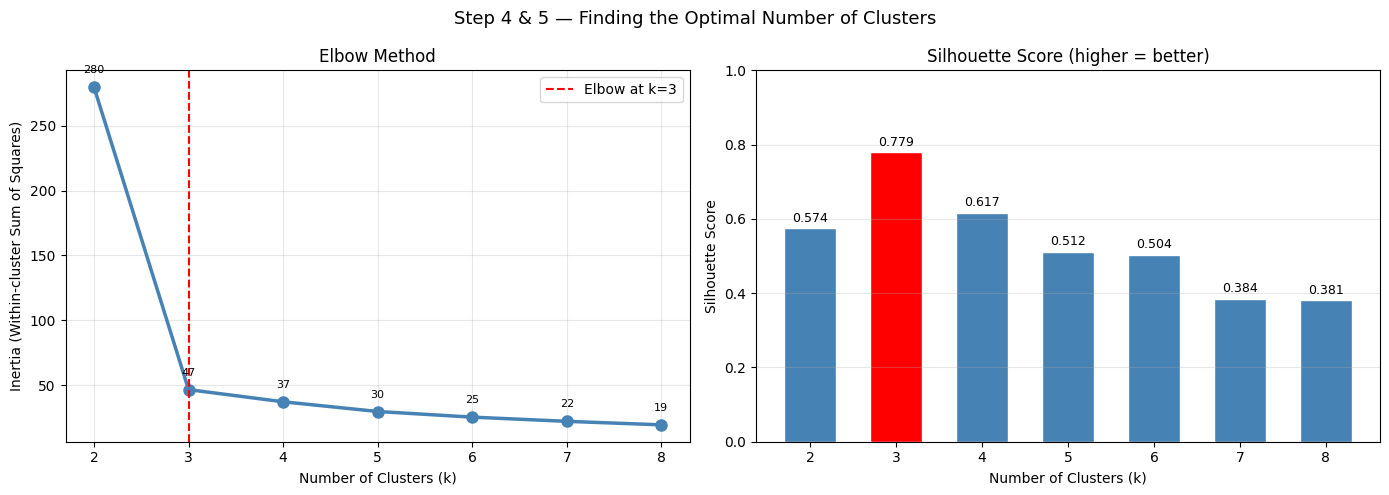

In [6]:
# ─────────────────────────────────────────────
# STEP 6: Visualize Elbow + Silhouette Side by Side
# ─────────────────────────────────────────────
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Step 4 & 5 — Finding the Optimal Number of Clusters", fontsize=13)
 
# Elbow plot
axes[0].plot(list(k_range), inertias, 'o-', color='steelblue',
             linewidth=2.5, markersize=8)
axes[0].axvline(x=best_k, color='red', linestyle='--',
                linewidth=1.5, label=f'Elbow at k={best_k}')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (Within-cluster Sum of Squares)')
axes[0].set_title('Elbow Method')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
for k, inertia in zip(k_range, inertias):
    axes[0].annotate(f'{inertia:.0f}', (k, inertia),
                     textcoords="offset points", xytext=(0, 10),
                     ha='center', fontsize=8)
 
# Silhouette plot
bar_colors = ['red' if k == best_k else 'steelblue' for k in k_range]
bars = axes[1].bar(list(k_range), silhouettes, color=bar_colors,
                   edgecolor='white', width=0.6)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score (higher = better)')
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim(0, 1)
for bar, s in zip(bars, silhouettes):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{s:.3f}', ha='center', va='bottom', fontsize=9)
 
plt.tight_layout()
plt.savefig("elbow_silhouette.png", dpi=150)
plt.show()

In [7]:
# ─────────────────────────────────────────────
# STEP 7: Apply K-Means with Optimal k
# n_init=10 → runs K-Means 10 times with different starting points
# and picks the best result (lowest inertia).
# This avoids getting stuck in a bad local minimum.
# ─────────────────────────────────────────────
 
print("\n" + "=" * 65)
print(f"STEP 7 — Apply K-Means with k={best_k}")
print("=" * 65)
 
kmeans     = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['group'] = kmeans.fit_predict(X_scaled)
 
centers_scaled = kmeans.cluster_centers_
centers_orig   = scaler.inverse_transform(centers_scaled)
 
print(f"Cluster centers (original scale):")
print(f"{'Group':>7}  {'Center Age':>12}  {'Center Spending':>17}")
print("-" * 40)
for i, (age, spend) in enumerate(centers_orig):
    print(f"  {i:>5}  {age:>12.1f}  {spend:>15,.0f} SAR")


STEP 7 — Apply K-Means with k=3
Cluster centers (original scale):
  Group    Center Age    Center Spending
----------------------------------------
      0          45.3            7,042 SAR
      1          60.2            1,908 SAR
      2          24.5            3,063 SAR


In [8]:
# ─────────────────────────────────────────────
# STEP 8: Analyze and Name Each Segment
# We use the cluster statistics to assign business-meaningful names.
# This is the "translation" step: data → business strategy.
# ─────────────────────────────────────────────
 
print("\n" + "=" * 65)
print("STEP 8 — Segment Analysis & Business Naming")
print("=" * 65)
 
segment_map = {}
for i in range(best_k):
    group     = df[df['group'] == i]
    avg_age   = group['age'].mean()
    avg_spend = group['monthly_spending'].mean()
 
    if avg_spend > 5000:
        name     = "🏆 High Value"
        strategy = "Real estate, premium cars, luxury travel"
    elif avg_age > 55:
        name     = "👴 Senior"
        strategy = "Healthcare, insurance, family products"
    else:
        name     = "🎯 Young"
        strategy = "Gaming, fashion, sports, tech gadgets"
 
    segment_map[i] = name
    df.loc[df['group'] == i, 'segment'] = name
 
    print(f"\n  {name}")
    print(f"  {'─'*45}")
    print(f"  Size              : {len(group)} customers  "
          f"({len(group)/len(df)*100:.0f}% of total)")
    print(f"  Average age       : {avg_age:.1f} years")
    print(f"  Average spending  : {avg_spend:,.0f} SAR/month")
    print(f"  Min / Max spending: {group['monthly_spending'].min():,} – "
          f"{group['monthly_spending'].max():,} SAR")
    print(f"  📣 Strategy       : {strategy}")


STEP 8 — Segment Analysis & Business Naming

  🏆 High Value
  ─────────────────────────────────────────────
  Size              : 120 customers  (40% of total)
  Average age       : 45.3 years
  Average spending  : 7,042 SAR/month
  Min / Max spending: 5,250 – 8,701 SAR
  📣 Strategy       : Real estate, premium cars, luxury travel

  👴 Senior
  ─────────────────────────────────────────────
  Size              : 100 customers  (33% of total)
  Average age       : 60.2 years
  Average spending  : 1,908 SAR/month
  Min / Max spending: 965 – 2,862 SAR
  📣 Strategy       : Healthcare, insurance, family products

  🎯 Young
  ─────────────────────────────────────────────
  Size              : 80 customers  (27% of total)
  Average age       : 24.5 years
  Average spending  : 3,063 SAR/month
  Min / Max spending: 1,919 – 4,548 SAR
  📣 Strategy       : Gaming, fashion, sports, tech gadgets



STEP 9 — Visualization


/var/folders/jx/sk64b25908l5sqybf60p4pfh0000gn/T/ipykernel_42798/34171982.py:62: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/jx/sk64b25908l5sqybf60p4pfh0000gn/T/ipykernel_42798/34171982.py:62: UserWarning: Glyph 128116 (\N{OLDER MAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/jx/sk64b25908l5sqybf60p4pfh0000gn/T/ipykernel_42798/34171982.py:62: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/jx/sk64b25908l5sqybf60p4pfh0000gn/T/ipykernel_42798/34171982.py:63: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.savefig("segmentation_results.png", dpi=150)
/var/folders/jx/sk64b25908l5sqybf60p4pfh0000gn/T/ipykernel_42798/34171982.py:63: UserWarning: Glyph 128116 (\N{OLDER MAN}) missing from font(s) DejaVu Sans.
  plt.savefig("segmentation_results.png", dpi=150)
/var/folders/jx/sk64b25908l5sqybf60p4pfh0000gn/T/ipyker

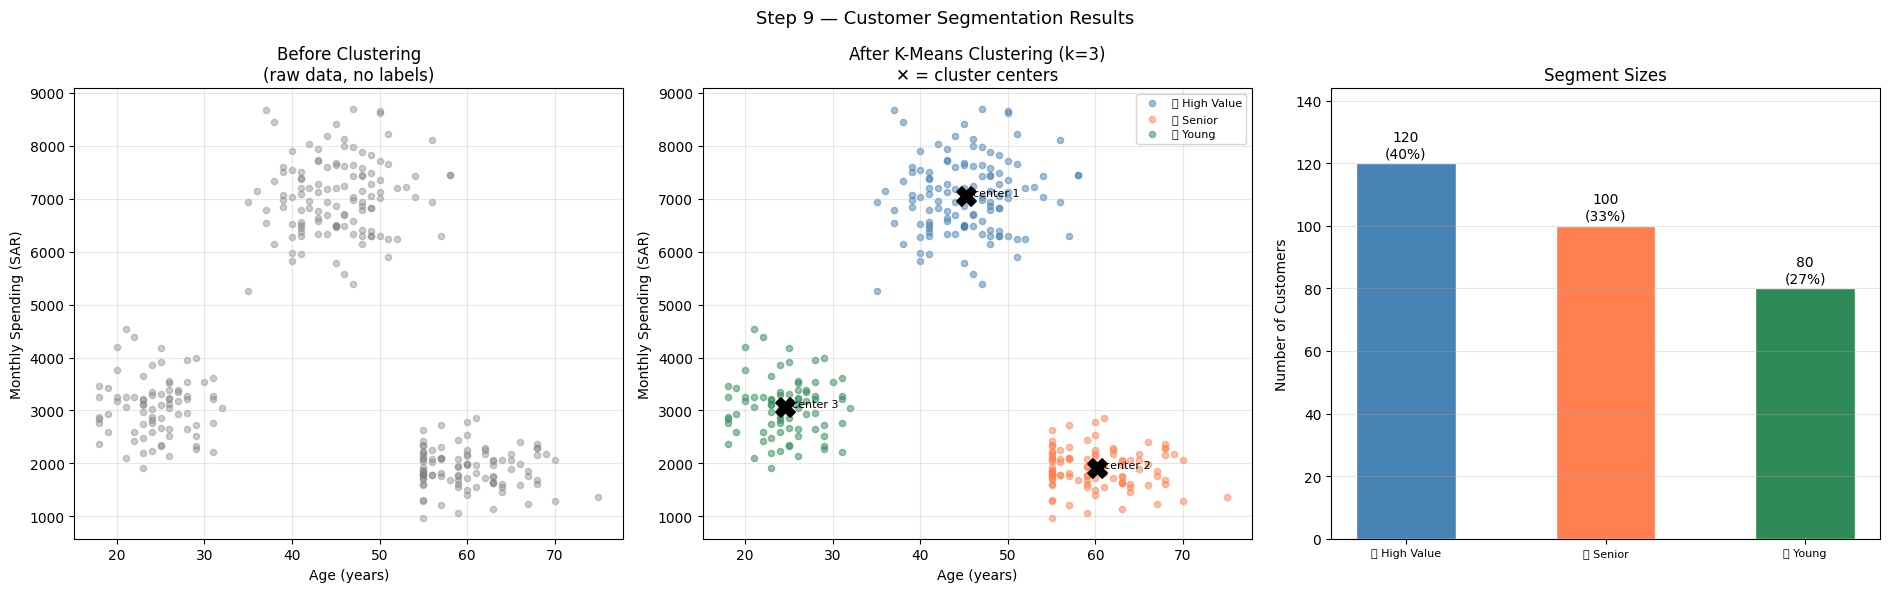

Plot saved → 'segmentation_results.png'


In [9]:
# ─────────────────────────────────────────────
# STEP 9: Visualization — Before vs After + Segment Detail
# ─────────────────────────────────────────────
 
print("\n" + "=" * 65)
print("STEP 9 — Visualization")
print("=" * 65)
 
seg_colors = {
    "🏆 High Value": "steelblue",
    "👴 Senior":     "coral",
    "🎯 Young":      "seagreen"
}
 
fig, axes = plt.subplots(1, 3, figsize=(19, 6))
fig.suptitle("Step 9 — Customer Segmentation Results", fontsize=13)
 
# ── Left: Before clustering ────────────────
axes[0].scatter(df['age'], df['monthly_spending'],
                alpha=0.4, color='gray', s=20)
axes[0].set_title("Before Clustering\n(raw data, no labels)")
axes[0].set_xlabel("Age (years)")
axes[0].set_ylabel("Monthly Spending (SAR)")
axes[0].grid(True, alpha=0.3)
 
# ── Middle: After clustering with centroids ─
for seg_name, color in seg_colors.items():
    mask = df['segment'] == seg_name
    if mask.sum() == 0:
        continue
    axes[1].scatter(df[mask]['age'], df[mask]['monthly_spending'],
                    c=color, label=seg_name, alpha=0.5, s=20)
 
for i, (age, spend) in enumerate(centers_orig):
    axes[1].scatter(age, spend, c='black', marker='X',
                    s=180, zorder=5, linewidths=1.5)
    axes[1].annotate(f'  center {i+1}', (age, spend),
                     fontsize=8, color='black')
 
axes[1].set_title(f"After K-Means Clustering (k={best_k})\n✕ = cluster centers")
axes[1].set_xlabel("Age (years)")
axes[1].set_ylabel("Monthly Spending (SAR)")
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)
 
# ── Right: Segment size bar chart ───────────
seg_counts = df['segment'].value_counts()
bars = axes[2].bar(seg_counts.index,
                   seg_counts.values,
                   color=[seg_colors.get(s, 'gray') for s in seg_counts.index],
                   edgecolor='white', width=0.5)
for bar, val in zip(bars, seg_counts.values):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f'{val}\n({val/len(df)*100:.0f}%)',
                 ha='center', va='bottom', fontsize=10)
axes[2].set_title("Segment Sizes")
axes[2].set_ylabel("Number of Customers")
axes[2].set_ylim(0, seg_counts.max() * 1.2)
axes[2].tick_params(axis='x', labelsize=8)
axes[2].grid(axis='y', alpha=0.3)
 
plt.tight_layout()
plt.savefig("segmentation_results.png", dpi=150)
plt.show()
print("Plot saved → 'segmentation_results.png'")

In [10]:
# ─────────────────────────────────────────────
# STEP 10: Business Summary Table
# Convert cluster analysis into an actionable marketing table.
# This is what you present to stakeholders — not raw numbers.
# ─────────────────────────────────────────────
 
print("\n" + "=" * 65)
print("STEP 10 — Business Summary Table")
print("=" * 65)
 
summary_rows = []
for seg_name in df['segment'].unique():
    group = df[df['segment'] == seg_name]
    summary_rows.append({
        'Segment':         seg_name,
        'Size':            len(group),
        'Avg Age':         f"{group['age'].mean():.0f} yrs",
        'Avg Spending':    f"{group['monthly_spending'].mean():,.0f} SAR",
        'Share':           f"{len(group)/len(df)*100:.0f}%",
    })
 
summary_df = pd.DataFrame(summary_rows).sort_values('Avg Spending', ascending=False)
print(summary_df.to_string(index=False))


STEP 10 — Business Summary Table
     Segment  Size Avg Age Avg Spending Share
🏆 High Value   120  45 yrs    7,042 SAR   40%
     🎯 Young    80  25 yrs    3,063 SAR   27%
    👴 Senior   100  60 yrs    1,908 SAR   33%


In [11]:
# ─────────────────────────────────────────────
# STEP 11: Use on Your Own Data
# This function replicates the README usage example.
# Load any CSV with 'age' and 'monthly_spending' columns.
# ─────────────────────────────────────────────
 
print("\n" + "=" * 65)
print("STEP 11 — Predict Segment for a New Customer")
print("=" * 65)
 
def predict_segment(age, monthly_spending):
    """
    Predicts the marketing segment for a new customer.
    Uses the trained KMeans model + StandardScaler.
 
    Args:
        age (int/float)              : Customer age in years.
        monthly_spending (int/float) : Monthly spending in SAR.
 
    Returns:
        str: Segment name with marketing strategy.
    """
    new_customer = np.array([[age, monthly_spending]])
    scaled       = scaler.transform(new_customer)
    group_id     = kmeans.predict(scaled)[0]
    seg_name     = segment_map[group_id]
 
    # Find distances to all cluster centers
    distances = np.linalg.norm(centers_scaled - scaled, axis=1)
    confidence = 1 - (distances[group_id] / distances.sum())
 
    print(f"  Customer     : Age={age}, Spending={monthly_spending:,} SAR/month")
    print(f"  Segment      : {seg_name}")
    print(f"  Confidence   : {confidence*100:.1f}%")
    print()
    return seg_name
 
print("Testing on 4 new customers:")
print()
predict_segment(age=24, monthly_spending=2800)
predict_segment(age=47, monthly_spending=7200)
predict_segment(age=63, monthly_spending=1700)
predict_segment(age=38, monthly_spending=5500)


STEP 11 — Predict Segment for a New Customer
Testing on 4 new customers:

  Customer     : Age=24, Spending=2,800 SAR/month
  Segment      : 🎯 Young
  Confidence   : 97.7%

  Customer     : Age=47, Spending=7,200 SAR/month
  Segment      : 🏆 High Value
  Confidence   : 97.2%

  Customer     : Age=63, Spending=1,700 SAR/month
  Segment      : 👴 Senior
  Confidence   : 96.1%

  Customer     : Age=38, Spending=5,500 SAR/month
  Segment      : 🏆 High Value
  Confidence   : 81.2%



'🏆 High Value'

In [12]:
# ─────────────────────────────────────────────
# STEP 12: Key Learnings
# ─────────────────────────────────────────────
 
print("=" * 65)
print("STEP 12 — Key Learnings")
print("=" * 65)
print("""
  1. Supervised vs Unsupervised Learning
     → Supervised   : Data + Labels → Model learns predefined classes
     → Unsupervised : Data only     → Model discovers hidden structure
 
  2. Why StandardScaler is CRITICAL for K-Means
     → K-Means uses Euclidean distance to assign clusters.
     → Without scaling: Spending (range 9500) dominates Age (range 57).
     → With scaling: both features contribute equally → fair clustering.
 
  3. Elbow Method
     → Plot inertia vs k. Look for where the curve "elbows".
     → Inertia always decreases — we want diminishing returns.
     → The elbow point = best balance between fit and simplicity.
 
  4. Silhouette Score
     → Confirms the elbow visually with a mathematical score.
     → Range: -1 to +1. Higher = better-separated clusters.
     → Always use BOTH methods together for more confidence.
 
  5. n_init=10 in KMeans
     → K-Means starts from random points each run (local minima risk).
     → Running 10 times and keeping the best avoids bad initializations.
 
  6. Business Translation
     → Raw cluster numbers mean nothing to stakeholders.
     → Always rename clusters using domain knowledge.
     → Connect each cluster to a concrete marketing strategy.
 
  7. Real Business Impact
     → Before: 1 generic campaign for all 300 customers
     → After : 3 targeted campaigns → higher relevance → higher ROI
""")
 
print("=" * 65)
print("✅ All steps complete.")
print("   Saved: 'data/customers.csv'")
print("   Saved: 'eda_raw_data.png'")
print("   Saved: 'elbow_silhouette.png'")
print("   Saved: 'segmentation_results.png'")
print("=" * 65)

STEP 12 — Key Learnings

  1. Supervised vs Unsupervised Learning
     → Supervised   : Data + Labels → Model learns predefined classes
     → Unsupervised : Data only     → Model discovers hidden structure

  2. Why StandardScaler is CRITICAL for K-Means
     → K-Means uses Euclidean distance to assign clusters.
     → Without scaling: Spending (range 9500) dominates Age (range 57).
     → With scaling: both features contribute equally → fair clustering.

  3. Elbow Method
     → Plot inertia vs k. Look for where the curve "elbows".
     → Inertia always decreases — we want diminishing returns.
     → The elbow point = best balance between fit and simplicity.

  4. Silhouette Score
     → Confirms the elbow visually with a mathematical score.
     → Range: -1 to +1. Higher = better-separated clusters.
     → Always use BOTH methods together for more confidence.

  5. n_init=10 in KMeans
     → K-Means starts from random points each run (local minima risk).
     → Running 10 times and 